<a href="https://colab.research.google.com/github/hwollwage/PCVK_2026/blob/main/week_06_15_244107020157.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [24]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=(figsize))
  for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, len(images), i+1)
    if len(img.shape) == 2:
      plt.imshow(img, cmap="gray")
    else:
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
  plt.show()

In [26]:
def convolution2d(image, kernel, stride, padding):
  image = image.astype(np.float32)
  kh, kw = kernel.shape

  if padding > 0:
    image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

  H, W = image.shape
  out_h = (H - kh) // stride + 1
  out_w = (W - kw) // stride + 1
  out = np.zeros((out_h, out_w), dtype=np.float32)

  for i in range(kh):
    for j in range(kw):
      out += kernel[i,j] * image[i:i + stride*out_h:stride, j:j + stride*out_w:stride]

  return out


In [27]:
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/gambar/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [28]:
# define kernel
kernels = {
    "Average 3x3": np.ones((3,3)) / 9,
    "Low Pass": np.array([[1,1,1],[1,4,1],[1,1,1]]) / 12,
    "High Pass": np.array([[-1,0,1],[-1,0,3],[-3,0,1]]),
    "Sharpen": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
    "Emboss": np.array([[-2,-1,0],[-1,1,1],[0,1,2]]),
    "Left Sobel": np.array([[1,0,-1],[2,0,-2],[1,0,-1]]),
    "Canny (kernel)": np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]),
}

kernel_size = 21
sigma = math.sqrt(kernel_size)
g = cv.getGaussianKernel(kernel_size, sigma)
kernels["21x21 gaussian blur"] = g @ g.T

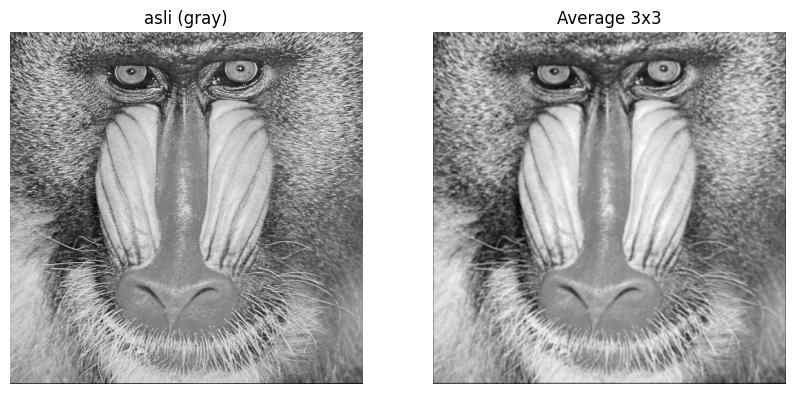

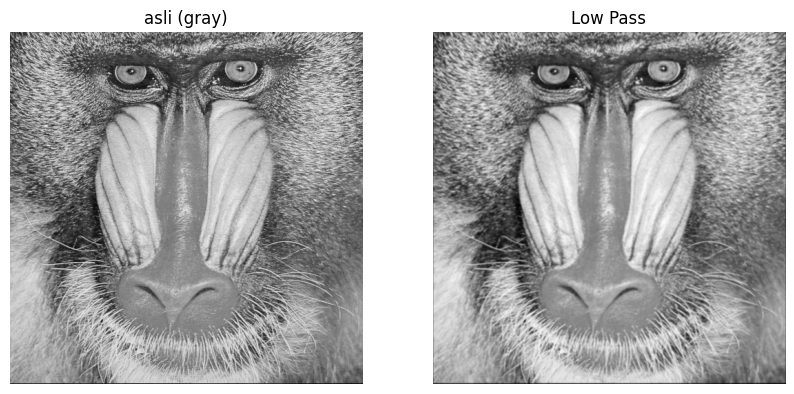

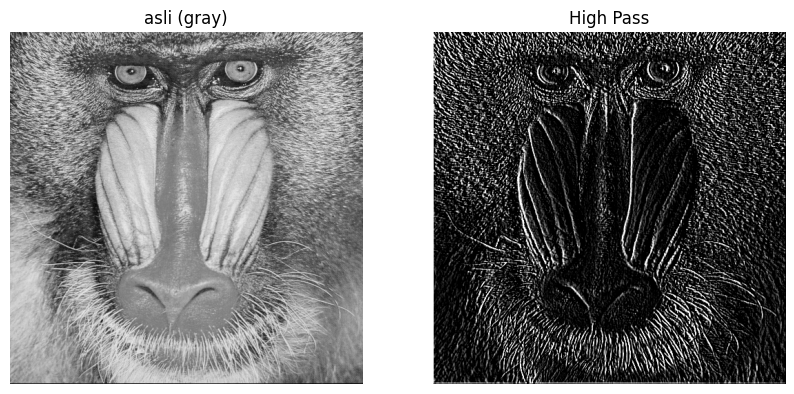

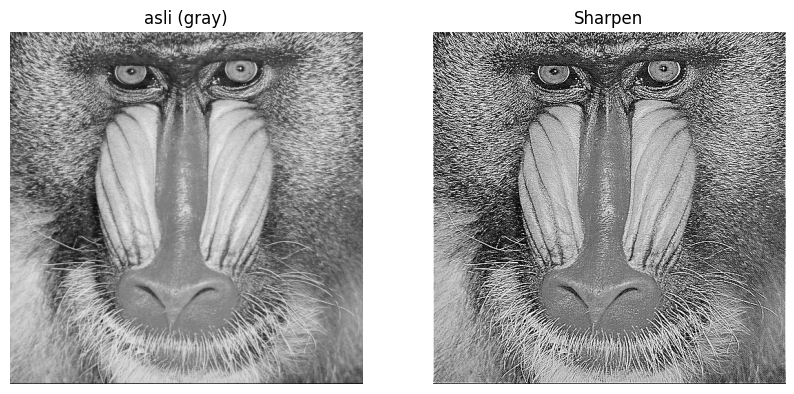

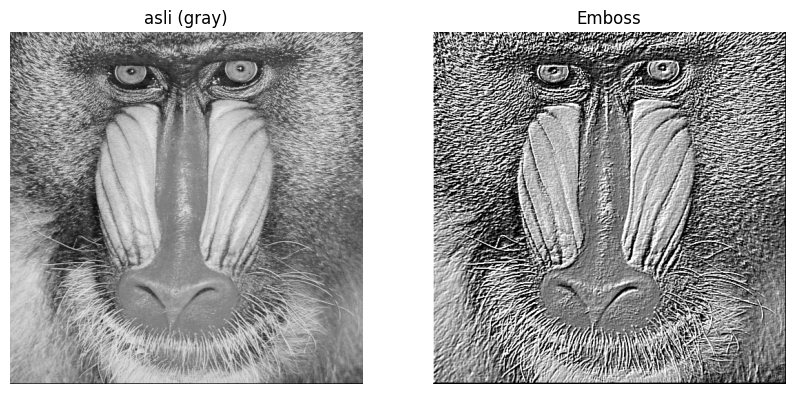

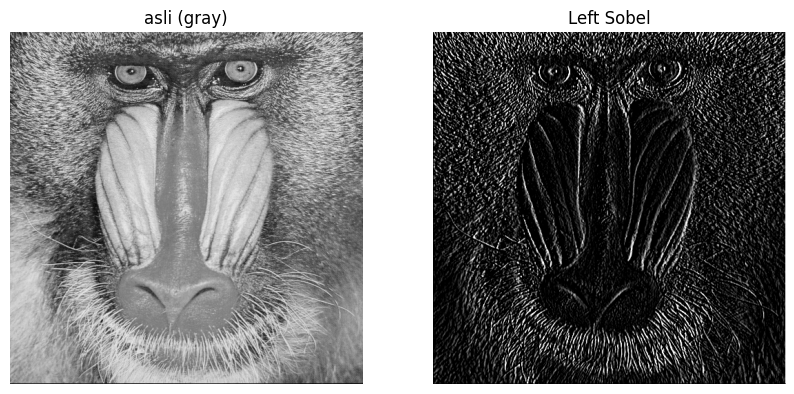

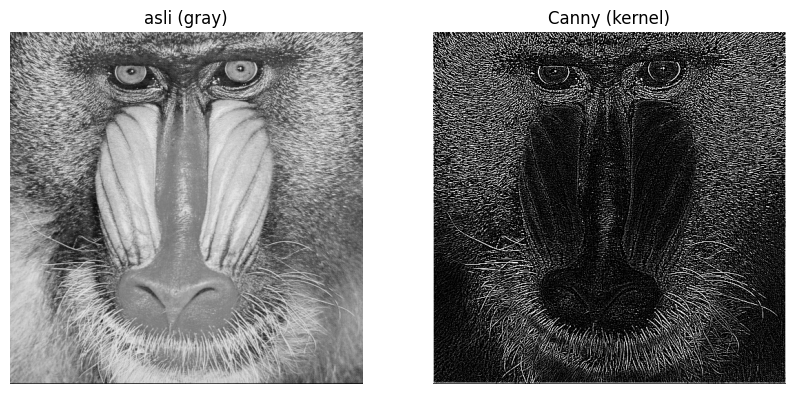

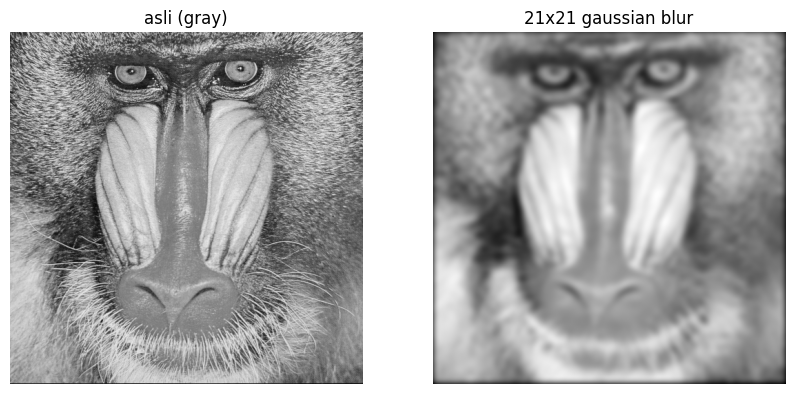

In [29]:
for name, k in kernels.items():
  res = convolution2d(img_gray, k, stride=1, padding=k.shape[0]//2)
  res = np.clip(res, 0, 255)
  show_side_by_side([img_gray, res], ["asli (gray)", name], figsize=(10,5))

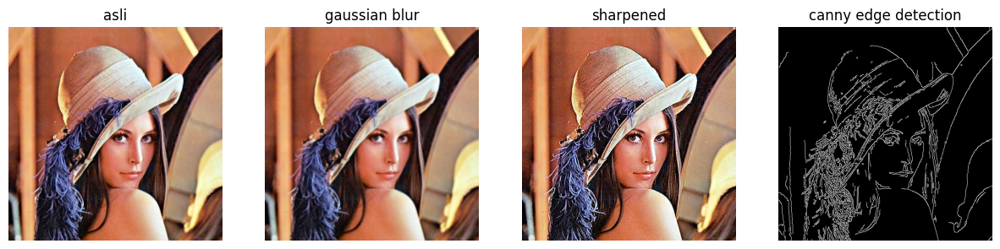

In [30]:
# EXPERIMENT 1 (gaussian, sharpen, canny)
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/gambar/lena.jpg')
blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges], ["asli", "gaussian blur", "sharpened", "canny edge detection"])

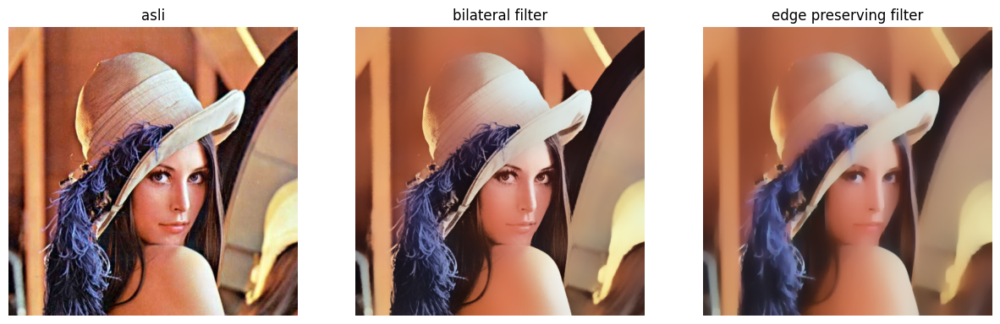

In [31]:
# EXPERIMENT 2 (bilateral & edge preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)
show_side_by_side([img, bilateral, edge_preserve], ["asli", "bilateral filter", "edge preserving filter"])

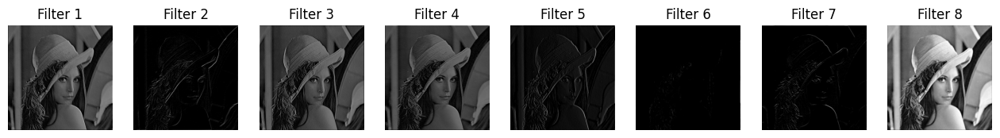

In [32]:
# EXPERIMENT 3 (feature map CNN)
import tensorflow as tf
x = cv.cvtColor(img, cv.COLOR_BGR2GRAY).astype(np.float32)/255.
x = x[np.newaxis, ..., np.newaxis]
conv = tf.keras.layers.Conv2D(8, (3,3), padding='same', activation='relu')
fmap = conv(x).numpy()[0]

plt.figure(figsize=(16,4))
for i in range(8):
  plt.subplot(1,8,i+1); plt.imshow(fmap[..., i], cmap='gray'); plt.axis('off')
  plt.title(f"Filter {i+1}")
plt.show()

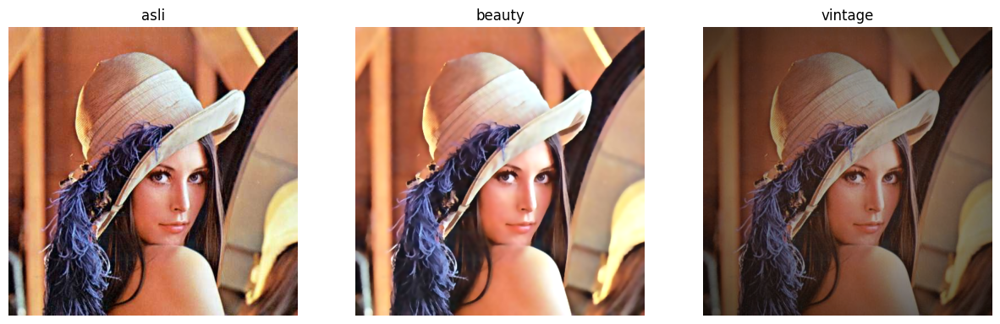

In [33]:
# EXPERIMENT 4 (beauty & vintage)
smooth = cv.bilateralFilter(img, 9, 75, 75)
beauty = cv.convertScaleAbs(smooth, alpha=1.05, beta=10)

warm = np.full_like(img, (30,60,110))
vint = cv.addWeighted(cv.convertScaleAbs(img, alpha=0.85, beta=10), 0.75, warm, 0.25, 0)
rows, cols = img.shape[:2]
kx = cv.getGaussianKernel(cols, cols/2); ky = cv.getGaussianKernel(rows, rows/2)
mask = (ky @ kx.T); mask = mask / mask.max()
vintage = (vint * mask[..., None]).astype(np.uint8)

show_side_by_side([img, beauty, vintage], ["asli", "beauty", "vintage"])

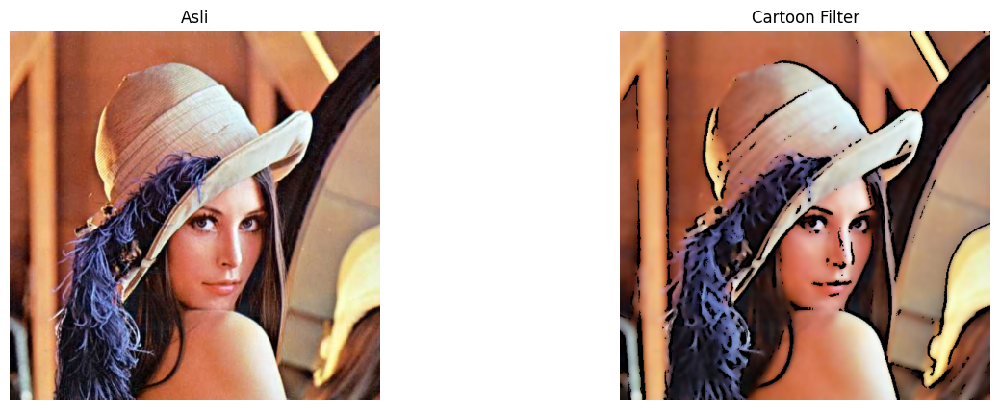

In [34]:
# EXPERIMENT 5 (cartoon)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)
cartoon = cv.bitwise_and(color, color, mask=edges)
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

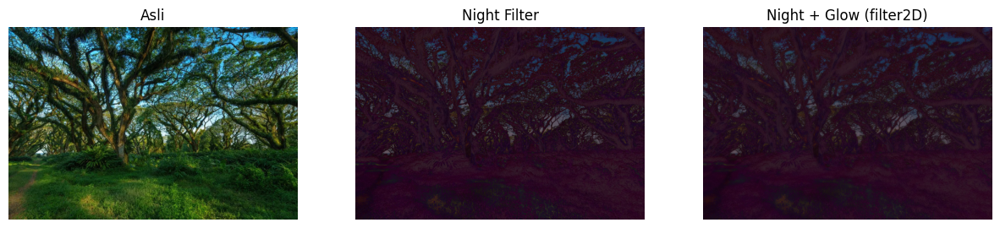

In [35]:
# EXPERIMENT 6 (night filter)
img = cv.imread("/content/drive/MyDrive/Colab Notebooks/gambar/djawatan.jpg")
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)
blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)
show_side_by_side([img, night, night_glow], ["Asli", "Night Filter", "Night + Glow (filter2D)"])

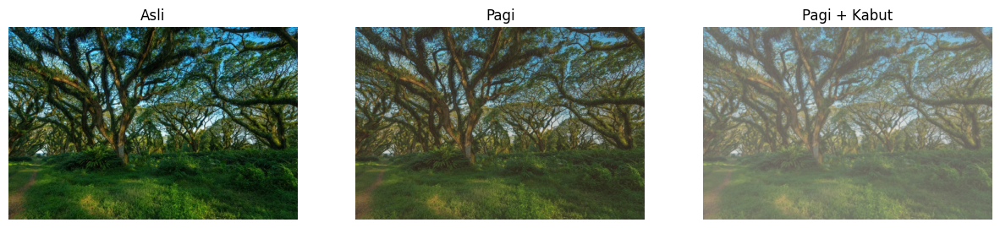

In [36]:
# EXPERIMENT 7 (pagi & kabut)
soft = cv.convertScaleAbs(img, alpha=0.9, beta=20)
warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)
k = cv.getGaussianKernel(3, 3); k = k @ k.T
kabut = cv.filter2D(pagi, -1, k)
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)
show_side_by_side([img, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])

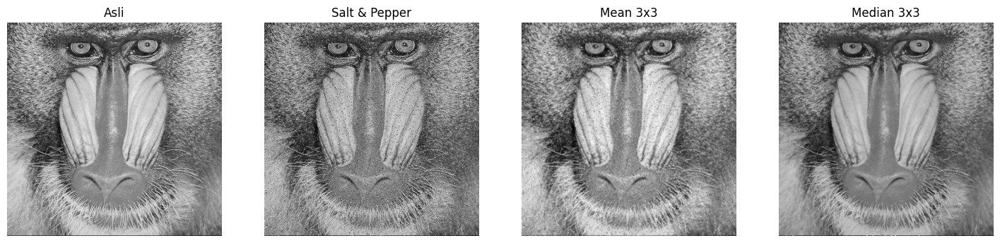

In [37]:
# TUGAS 1 (mean v median salt n pepper)
def add_salt_pepper(image, amount=0.05):
    noisy = image.copy()
    n = int(amount * image.size)
    ys = np.random.randint(0, image.shape[0], n)
    xs = np.random.randint(0, image.shape[1], n)
    noisy[ys[:n//2], xs[:n//2]] = 255 # salt
    noisy[ys[n//2:], xs[n//2:]] = 0 # pepper
    return noisy

noisy  = add_salt_pepper(img_gray, 0.05)
mean_f = cv.blur(noisy, (3,3))
med_f  = cv.medianBlur(noisy, 3)
show_side_by_side([img_gray, noisy, mean_f, med_f], ["Asli", "Salt & Pepper", "Mean 3x3", "Median 3x3"], figsize=(18,5))

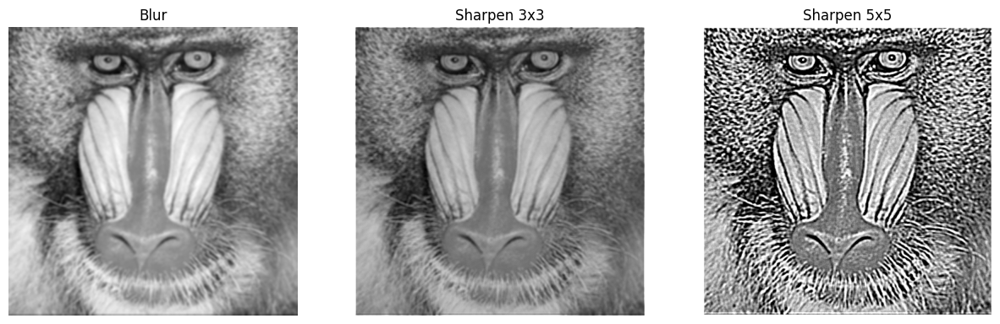

In [38]:
# TUGAS 2 (kernel sharpening 3x3 v 5x5)
k3 = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
k5 = -np.ones((5,5), dtype=np.float32); k5[2,2] = 25

blurry = cv.GaussianBlur(img_gray, (7,7), 2)
s3 = np.clip(convolution2d(blurry, k3, 1, 1), 0, 255)
s5 = np.clip(convolution2d(blurry, k5, 1, 2), 0, 255)

show_side_by_side([blurry, s3, s5], ["Blur", "Sharpen 3x3", "Sharpen 5x5"], figsize=(15,5))

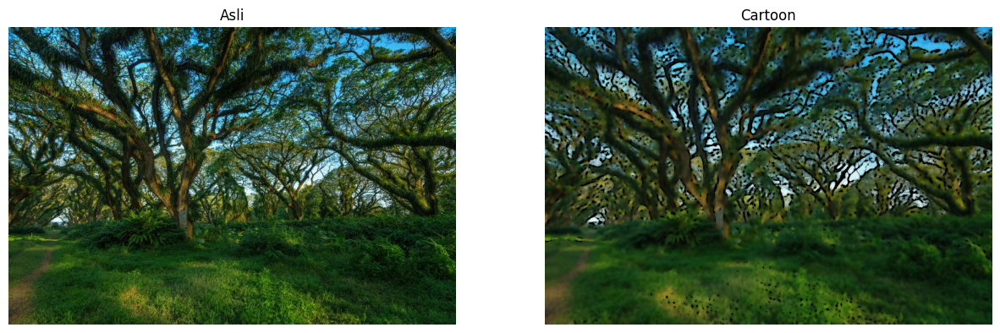

In [39]:
# TUGAS 3 (cartoon(img))
def cartoon(image):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)          # deteksi tepi
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)
    return cv.bitwise_and(color, color, mask=edges)

result = cartoon(img)
show_side_by_side([img, result], ["Asli", "Cartoon"])